# Análisis de Caso – Reducción dimensional (PCA y t-SNE)

En este notebook resolvemos el caso de VisionData, donde hay un dataset de encuestas con muchas variables (alta dimensionalidad).

Objetivos:

1. Reducir dimensionalidad con PCA y t-SNE.
2. Generar visualizaciones 2D.
3. Comparar resultados y elegir qué técnica usar para presentar insights a marketing.


In [9]:
# 1. Cargar librerías y configurar entorno

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

# Para reproducibilidad
RANDOM_STATE = 42

plt.style.use('seaborn-v0_8')

## 1. Cargar o generar el dataset

En el caso real usaríamos un archivo tipo `survey_data.csv` con más de 50 columnas.

Aquí haremos dos opciones:

1. Opción A (por defecto): generar un dataset sintético con 1000 filas y 60 columnas.
2. Opción B: comentar la opción A y cargar tu propio archivo con `pd.read_csv`.


In [10]:
# 1.1 Opción A: generar dataset sintético

n_samples = 1000
n_features = 60

np.random.seed(RANDOM_STATE)

# Simulamos 3 segmentos de clientes
cluster_1 = np.random.normal(loc=0.0, scale=1.0, size=(n_samples // 3, n_features))
cluster_2 = np.random.normal(loc=2.0, scale=1.2, size=(n_samples // 3, n_features))
cluster_3 = np.random.normal(loc=-1.5, scale=0.8, size=(n_samples - 2 * (n_samples // 3), n_features))

X = np.vstack([cluster_1, cluster_2, cluster_3])

column_names = [f"Q{i}" for i in range(1, n_features + 1)]
df = pd.DataFrame(X, columns=column_names)

# Etiquetas "reales" solo para evaluar visualmente
true_labels = np.array(
    [0] * (n_samples // 3)
    + [1] * (n_samples // 3)
    + [2] * (n_samples - 2 * (n_samples // 3))
)

df.head()

,Q1,Q2,Q3,Q4,Q5,Q6,Q7,Q8,Q9,Q10,...,Q51,Q52,Q53,Q54,Q55,Q56,Q57,Q58,Q59,Q60
0,0.496714,-0.138264,0.647689,1.523030,-0.234153,-0.234137,1.579213,0.767435,-0.469474,0.542560,...,0.324084,-0.385082,-0.676922,0.611676,1.031000,0.931280,-0.839218,-0.309212,0.331263,0.975545
1,-0.479174,-0.185659,-1.106335,-1.196207,0.812526,1.356240,-0.072010,1.003533,0.361636,-0.645120,...,-1.918771,-0.026514,0.060230,2.463242,-0.192361,0.301547,-0.034712,-1.168678,1.142823,0.751933
2,0.791032,-0.909387,1.402794,-1.401851,0.586857,2.190456,-0.990536,-0.566298,0.099651,-0.503476,...,-0.889514,-0.815810,-0.077102,0.341152,0.276691,0.827183,0.013002,1.453534,-0.264657,2.720169
3,0.625667,-0.857158,-1.070892,0.482472,-0.223463,0.714000,0.473238,-0.072829,-0.846794,-1.514847,...,-0.730367,0.216459,0.045572,-0.651600,2.143944,0.633919,-2.025143,0.186454,-0.661786,0.852433
4,-0.792521,-0.114736,0.504987,0.865755,-1.200296,-0.334501,-0.474945,-0.653329,1.765454,0.404982,...,-0.208122,-0.493001,-0.589365,0.849602,0.357015,-0.692910,0.899600,0.307300,0.812862,0.629629


## 2. Exploración y limpieza

En esta sección revisamos tamaño del dataset, tipos de datos y valores nulos.


In [11]:
# 2.1 Exploración inicial

print("Dimensiones del dataset:", df.shape)
print("\nTipos de datos y nulos:")
print(df.info())

print("\nCantidad total de valores nulos:", df.isnull().sum().sum())

print("\nEstadísticos descriptivos (primeras columnas):")
display(df.iloc[:, :5].describe())

Dimensiones del dataset: (1000, 60)

Tipos de datos y nulos:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 60 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Q1      1000 non-null   float64
 1   Q2      1000 non-null   float64
 2   Q3      1000 non-null   float64
 3   Q4      1000 non-null   float64
 4   Q5      1000 non-null   float64
 5   Q6      1000 non-null   float64
 6   Q7      1000 non-null   float64
 7   Q8      1000 non-null   float64
 8   Q9      1000 non-null   float64
 9   Q10     1000 non-null   float64
 10  Q11     1000 non-null   float64
 11  Q12     1000 non-null   float64
 12  Q13     1000 non-null   float64
 13  Q14     1000 non-null   float64
 14  Q15     1000 non-null   float64
 15  Q16     1000 non-null   float64
 16  Q17     1000 non-null   float64
 17  Q18     1000 non-null   float64
 18  Q19     1000 non-null   float64
 19  Q20     1000 non-null   float64
 20  Q21     1000 n

,Q1,Q2,Q3,Q4,Q5
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,0.192997,0.104476,0.184274,0.179394,0.227029
std,1.686342,1.730584,1.766272,1.726017,1.735503
min,-3.955881,-3.911553,-3.404553,-4.215132,-3.582989
25%,-1.116585,-1.272023,-1.194800,-1.109784,-1.189595
50%,0.031499,-0.061879,-0.072593,-0.001346,0.049864
75%,1.431967,1.355096,1.327405,1.426139,1.581068
max,6.322898,5.553540,5.789688,5.766937,5.005180


## 3. Escalado de variables

Antes de aplicar PCA y t-SNE, escalamos las variables para que todas estén en una escala comparable.

Usamos la estandarización:

\[
Z_j = \frac{X_j - \text{media}(X_j)}{\text{desv\_est}(X_j)}
\]

Interpretación: \(Z_j\) indica cuántas desviaciones estándar por encima o por debajo de la media está cada observación en la variable \(j\).

Mini–ejemplo: si una variable tiene media 50 y desviación estándar 10, y un cliente tiene valor 70, entonces
\(Z = (70 - 50) / 10 = 2\), es decir, 2 desvíos estándar por encima de la media.


In [12]:
# 3.1 Aplicar StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

print("Forma de X_scaled:", X_scaled.shape)
print("Media aproximada (primeras 5 columnas):", X_scaled[:, :5].mean(axis=0))
print("Desvío estándar (primeras 5 columnas):", X_scaled[:, :5].std(axis=0))

Forma de X_scaled: (1000, 60)
Media aproximada (primeras 5 columnas): [6.97997216e-16 8.20177259e-18 5.99131855e-16 9.08162434e-17
 2.86770607e-16]
Desvío estándar (primeras 5 columnas): [1. 1. 1. 1. 1.]


## 4. PCA: ajuste y visualización 2D

### 4.1 ¿Qué hace PCA?

El Análisis de Componentes Principales (PCA) busca nuevas variables (componentes) que:

1. Sean combinaciones lineales de las variables originales.
2. Expliquen la máxima varianza posible. [web:2][web:5]

Un componente típico se ve así:

\[
PC_1 = w_1 X_1 + w_2 X_2 + \dots + w_p X_p
\]

Los componentes se ordenan de mayor a menor varianza explicada: el primero captura la mayor parte de la información, el segundo la segunda mayor, etc. [web:3][web:9]


In [13]:
# 4.2 Ajustar PCA a 2 componentes

pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

print("Forma de la proyección PCA:", X_pca.shape)
print("Varianza explicada por cada componente:", pca.explained_variance_ratio_)
print("Varianza explicada total (2 componentes):", pca.explained_variance_ratio_.sum())

Forma de la proyección PCA: (1000, 2)
Varianza explicada por cada componente: [0.67081726 0.00873278]
Varianza explicada total (2 componentes): 0.6795500448212111


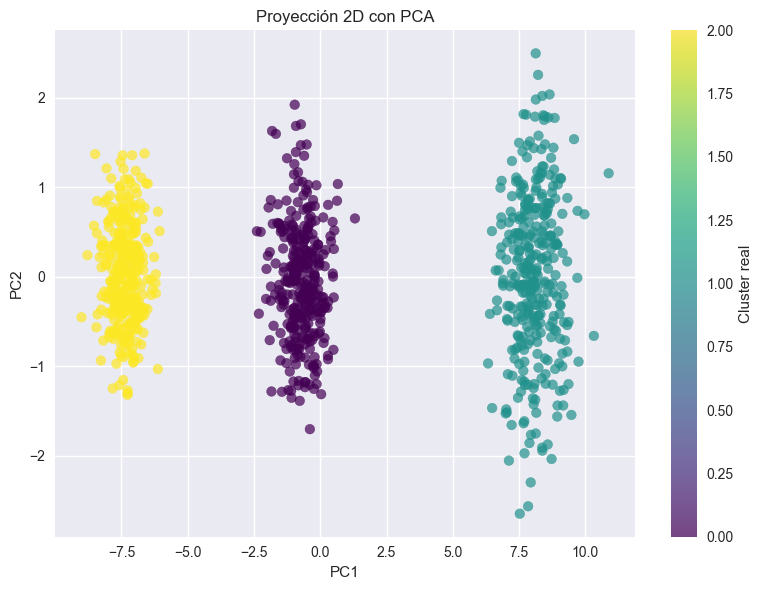

In [14]:
# 4.3 Visualización 2D de PCA

plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=true_labels,
    cmap='viridis',
    alpha=0.7
)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Proyección 2D con PCA')
cbar = plt.colorbar(scatter)
cbar.set_label('Cluster real')
plt.tight_layout()
plt.show()

## 5. t-SNE: ajuste y visualización 2D

### 5.1 ¿Qué hace t-SNE?

t-SNE (t-Distributed Stochastic Neighbor Embedding) es una técnica no lineal de reducción de dimensionalidad pensada para visualización. [web:7][web:16]

Idea central:

1. En el espacio original, calcula similitudes entre puntos (quién es vecino de quién).
2. En el espacio 2D, intenta colocar los puntos de forma que esas vecindades se mantengan.
3. Puntos similares acaban cerca; puntos muy diferentes, lejos. [web:10][web:13]


In [15]:
# 5.2 Ajustar t-SNE a 2 componentes

tsne = TSNE(
    n_components=2,
    random_state=RANDOM_STATE,
    perplexity=30,
    learning_rate=200,
    init='pca'
)


X_tsne = tsne.fit_transform(X_scaled)

print('Forma de la proyección t-SNE:', X_tsne.shape)

Forma de la proyección t-SNE: (1000, 2)


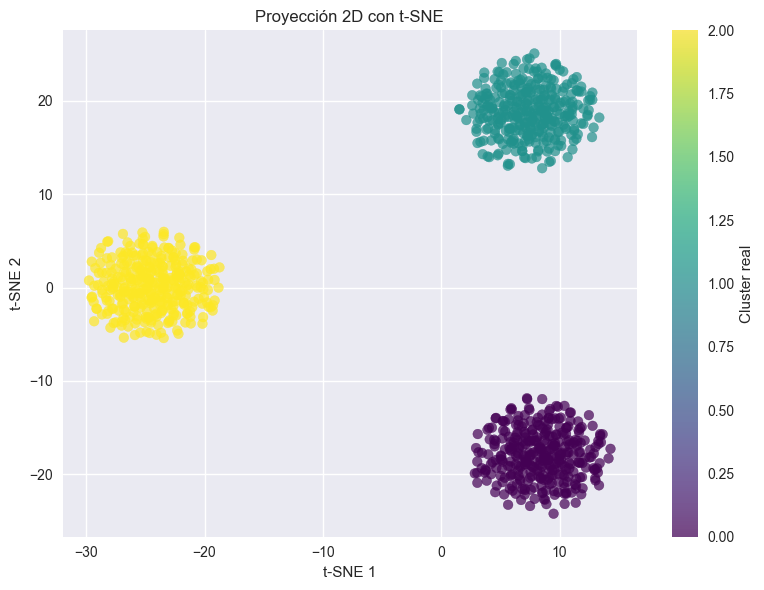

In [16]:
# 5.3 Visualización 2D de t-SNE

plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    X_tsne[:, 0],
    X_tsne[:, 1],
    c=true_labels,
    cmap='viridis',
    alpha=0.7
)
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.title('Proyección 2D con t-SNE')
cbar = plt.colorbar(scatter)
cbar.set_label('Cluster real')
plt.tight_layout()
plt.show()

## 6. Comparación visual PCA vs t-SNE

Para comparar:

1. Observa el gráfico de PCA:
   - ¿Los colores (segmentos) aparecen relativamente separados o se mezclan?
   - ¿Parece haber gradientes o transiciones suaves?

2. Observa el gráfico de t-SNE:
   - ¿Ves grupos más compactos y bien diferenciados?
   - ¿Los clústers se ven más aislados y fáciles de distinguir?

En general:

- PCA captura mejor la estructura global de varianza, pero puede no separar bien clústers no lineales. [web:3][web:5]
- t-SNE está optimizado para conservar vecindades locales y suele separar mejor clústers complejos, sacrificando la interpretación de ejes y distancias globales. [web:7][web:10][web:16]


## 7. Conclusiones para marketing y reflexión

### 7.1 ¿Qué técnica usaría para mostrar insights?

- Si el foco es interpretar los ejes (por ejemplo, “este eje representa clientes más digitales vs más tradicionales”), PCA es más adecuado, porque los componentes son combinaciones lineales de las variables originales y se puede analizar qué variables pesan más en cada componente. [web:2][web:5]
- Si el foco es mostrar segmentos muy claros y visuales (clústers bien separados para justificar una segmentación), t-SNE suele producir mapas donde los grupos se ven más nítidos, aunque sus ejes no tienen una interpretación directa. [web:7][web:16]

Una estrategia razonable en un contexto de marketing:

1. Usar t-SNE para una visualización muy clara de los grupos.
2. Complementar con PCA (o análisis de loadings de PCA) para explicar qué variables diferencian a esos grupos.

### 7.2 Limitaciones observadas

**PCA**:

- Lineal: si la estructura de los datos es muy no lineal, puede mezclar clústers. [web:3][web:5]
- Sensible al escalado: sin estandarizar, las variables de mayor rango dominan. [web:3]
- Componentes a veces difíciles de interpretar si intervienen muchas variables.

**t-SNE**:

- Costoso computacionalmente, sobre todo con muchos puntos. [web:10][web:13]
- Hiperparámetros sensibles (perplexity, learning_rate); resultados pueden cambiar entre corridas. [web:10][web:13]
- No preserva bien la estructura global: las distancias entre clústers en el mapa no deben interpretarse literalmente. [web:16]

### 7.3 ¿Qué haría con un volumen de datos mucho mayor?

1. Aplicar primero PCA para reducir de, por ejemplo, 100 variables a 30–50, y recién ahí aplicar t-SNE sobre ese espacio reducido. [web:9][web:2]
2. Considerar UMAP como alternativa a t-SNE, ya que suele escalar mejor y mantener mejor el equilibrio entre estructura local y global. [web:11][web:14]
3. Usar una muestra representativa del dataset para visualización (por ejemplo, 20–30 mil puntos), manteniendo el dataset completo para el modelado predictivo. [web:14]


## 8. Extra: guardar gráficos e informe corto

En esta sección (opcional) se muestran ejemplos de cómo guardar las figuras en archivos PNG y generar un archivo `.md` con un informe breve.


In [17]:
# 8.1 Guardar figuras de PCA y t-SNE en archivos PNG

# Figura PCA
plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=true_labels,
    cmap='viridis',
    alpha=0.7
)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Proyección 2D con PCA')
cbar = plt.colorbar(scatter)
cbar.set_label('Cluster real')
plt.tight_layout()
plt.savefig('pca_proyeccion_2d.png', dpi=150)
plt.close()

# Figura t-SNE
plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    X_tsne[:, 0],
    X_tsne[:, 1],
    c=true_labels,
    cmap='viridis',
    alpha=0.7
)
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.title('Proyección 2D con t-SNE')
cbar = plt.colorbar(scatter)
cbar.set_label('Cluster real')
plt.tight_layout()
plt.savefig('tsne_proyeccion_2d.png', dpi=150)
plt.close()

print('Figuras guardadas como pca_proyeccion_2d.png y tsne_proyeccion_2d.png')

Figuras guardadas como pca_proyeccion_2d.png y tsne_proyeccion_2d.png


In [18]:
# 8.2 Generar un informe corto en formato .md

informe_md = (
    "# Informe – Reducción dimensional en encuestas de clientes\n\n"
    "## Técnica recomendada\n\n"
    "En este caso, se recomienda utilizar una combinación de PCA y t-SNE para presentar insights al equipo de marketing:\n\n"
    "1. t-SNE para la visualización principal de los clústers de clientes, ya que genera un mapa 2D donde los grupos aparecen bien separados y son fáciles de identificar a simple vista.\n"
    "2. PCA como apoyo para la interpretación de los factores subyacentes, analizando qué variables contribuyen más a los componentes principales que separan esos grupos.\n\n"
    "## Principales hallazgos\n\n"
    "- El dataset presenta una estructura segmentada: en ambas proyecciones 2D (PCA y t-SNE) se observan grupos de clientes con patrones similares de respuesta.\n"
    "- La proyección con t-SNE muestra clústers más compactos y claramente diferenciados, lo que facilita la comunicación visual de los segmentos.\n"
    "- La proyección con PCA conserva bien la estructura global de los datos y permite interpretar los ejes en términos de combinaciones de variables originales.\n\n"
    "## Reflexión crítica\n\n"
    "La reducción dimensional es una herramienta muy útil para trabajar con encuestas de alta dimensionalidad, ya que permite acelerar el entrenamiento de modelos y facilitar la visualización de patrones y agrupamientos que serían imposibles de ver en el espacio original.\n\n"
    "Sin embargo, es importante tener en cuenta que:\n\n"
    "- PCA es lineal y puede no capturar relaciones complejas entre variables; además, los componentes pueden ser difíciles de explicar si intervienen muchas variables.\n"
    "- t-SNE produce visualizaciones muy expresivas, pero sus ejes no tienen una interpretación directa, no preserva distancias globales y es sensible a los hiperparámetros y al tamaño del dataset.\n\n"
    "En contextos con volúmenes de datos aún mayores, una buena práctica es combinar PCA (para reducir ruido y dimensionalidad) con técnicas no lineales como t-SNE o UMAP, y trabajar con muestras representativas para visualización.\n"
)

with open('informe_reduccion_dimensional.md', 'w', encoding='utf-8') as f:
    f.write(informe_md)

print('Informe guardado como informe_reduccion_dimensional.md')

Informe guardado como informe_reduccion_dimensional.md
